# 03 — Exploratory Data Analysis
## Global Job Market Compensation Analysis

**Objective:** Every analysis in this notebook answers a specific business question relevant to a People Analytics / compensation intelligence use case. Format per question: Question -> Code -> Visualization -> Interpretation -> Business Insight -> Recommendation.

**Standing caveats carried from Phases 1-4 (apply throughout):**
- `salary` is assumed USD-normalized across countries -- not independently verifiable from the data.
- This dataset shows signs of synthetic generation (balanced categories, no missingness) -- some patterns reflect generation design rather than organic labor-market behavior. We call this out wherever it's relevant.
- `salary_band`, `high_salary_indicator`, and `salary_per_experience_year` are salary-derived -- used here for description only, never as model predictors (see Phase 4).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet('../data/processed/job_market_features.parquet')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded: 499,972 rows x 20 columns


## Q1. Which countries pay the highest salaries?

**Business relevance:** anchors any cross-country compensation benchmarking decision a comp team would make.

                               mean    median           std  count
country                                                           
Switzerland           276974.982152  286346.0  79767.500687  22523
United States         265323.397418  269254.0  80159.247557  45232
Singapore             250579.859411  250247.0  80036.458719  22733
United Arab Emirates  243197.590877  241329.5  79502.429369  22624
Germany               234285.484805  230316.5  79120.554355  22836
United Kingdom        226348.202658  221037.0  78082.924041  22871
Australia             225973.211099  220400.0  77615.410287  22435
Canada                225842.068558  220830.0  76302.474003  22769
Ireland               217888.918678  212155.0  76211.422486  22958
Netherlands           217205.046190  211851.0  75120.777006  22754
Japan                 217188.485173  210861.0  75315.023580  22425
Sweden                215875.220340  209854.0  75780.637885  22792
France                207567.121597  201676.0  73640.963695  2

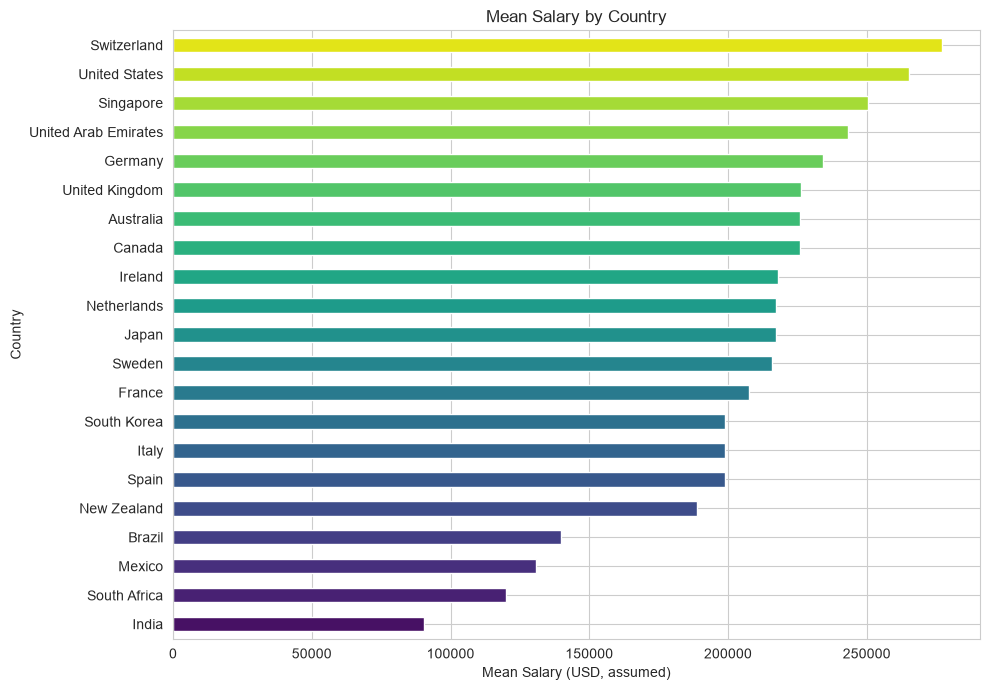

In [2]:
country_salary = df.groupby('country', observed=True)['salary'].agg(['mean','median','std','count']).sort_values('mean', ascending=False)
print(country_salary)

fig, ax = plt.subplots(figsize=(10,7))
country_salary['mean'].sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(country_salary)))

ax.set_xlabel('Mean Salary (USD, assumed)')
ax.set_ylabel('Country')
ax.set_title('Mean Salary by Country')
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q1_country_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Switzerland ($276,975 mean) and the US ($265,323) lead, roughly 3.1x India's mean ($90,384), the lowest in the dataset. The ranking (Switzerland > US > Singapore > UAE > Western Europe > Southern Europe > Brazil/Mexico/South Africa > India) is smooth and monotonic -- consistent with a designed cost-of-living-style gradient rather than noisy real-world data.

**Business insight:** Under our stated USD-normalization assumption, a comp team benchmarking a role in Switzerland vs. India would see a ~3x nominal gap. This is directionally consistent with real-world global pay gradients, but the *smoothness* of the gradient here is a data-generation signature -- real cross-country data is rarely this clean.

**Recommendation:** Any pay-benchmarking tool built from this analysis should clearly label figures as "assumed USD-normalized" and avoid presenting country rankings as precise multipliers -- they're directionally useful, not audit-grade.

## Q2. Which cities offer the best opportunities?

**Business relevance:** city-level benchmarking for location-based offer decisions. **Caveat:** the US has two cities (New York, San Francisco) while every other country has one -- so city comparisons are not perfectly balanced across countries.

                        mean    median  count
city                                         
Zurich         276974.982152  286346.0  22523
New York       265403.252012  269868.0  22737
San Francisco  265242.683752  268755.0  22495
Singapore      250579.859411  250247.0  22733
Dubai          243197.590877  241329.5  22624
Berlin         234285.484805  230316.5  22836
London         226348.202658  221037.0  22871
Sydney         225973.211099  220400.0  22435
Toronto        225842.068558  220830.0  22769
Dublin         217888.918678  212155.0  22958
Amsterdam      217205.046190  211851.0  22754
Tokyo          217188.485173  210861.0  22425
Stockholm      215875.220340  209854.0  22792
Paris          207567.121597  201676.0  22739
Seoul          199023.475490  192564.0  22583
Milan          198842.477080  192504.0  22971
Madrid         198833.847104  192193.0  22839
Auckland       188950.065475  181828.0  22665
Sao Paulo      139750.510561  133931.5  23010
Mexico City    130787.245210  1259

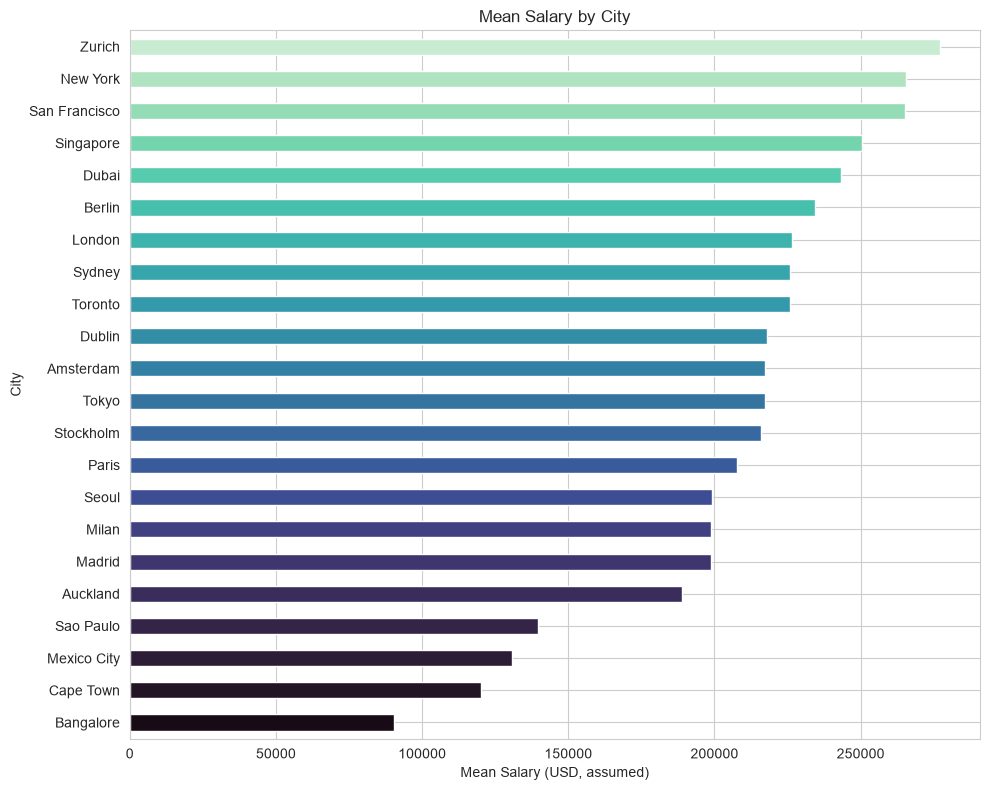

In [3]:
city_salary = df.groupby('city', observed=True)['salary'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print(city_salary)

fig, ax = plt.subplots(figsize=(10,8))
city_salary['mean'].sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('mako', len(city_salary)))

ax.set_xlabel('Mean Salary (USD, assumed)')
ax.set_ylabel("City")
ax.set_title('Mean Salary by City')
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q2_city_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** City rankings mirror country rankings almost exactly (Zurich highest at $276,975, Bangalore lowest at $90,384), since each country maps to one city except the US, which splits into New York ($265,403) and San Francisco ($265,243) -- nearly identical, unlike the real world where SF Bay Area tech pay typically exceeds NYC's broader market.

**Business insight:** City-level analysis adds no information beyond country-level here, except revealing that the US's two cities were generated with matching distributions rather than SF's real tech-salary premium.

**Recommendation:** Don't market this project's "city analysis" as adding new insight beyond country-level; be upfront that with only 22 cities (21 of them 1-per-country), this is really a country analysis with city labels attached.

## Q3. Highest-paying occupations

**Business relevance:** role-level pay benchmarking -- the core use case for a comp team.

                               mean    median           std  count
occupation                                                        
AI Engineer           252146.871926  257400.0  86972.943496  41765
Product Manager       251254.229331  256453.5  87422.746930  41826
Cloud Engineer        242811.519409  244940.5  86362.836680  41734
Data Scientist        233242.205098  233290.0  85652.968618  41507
Software Engineer     223667.326878  221790.0  84613.536751  41673
Operations Manager    213447.475852  210618.0  81384.446358  41639
Financial Analyst     202581.415425  198506.0  79113.480574  41815
UX Designer           192173.979590  187592.0  76306.765419  41842
Business Analyst      191619.731466  187119.0  75762.016820  41302
Data Analyst          179691.180656  175197.5  72221.620525  41770
Marketing Specialist  156345.184921  151683.5  64105.325086  41542
HR Analyst            144604.000337  140343.0  59599.271197  41557


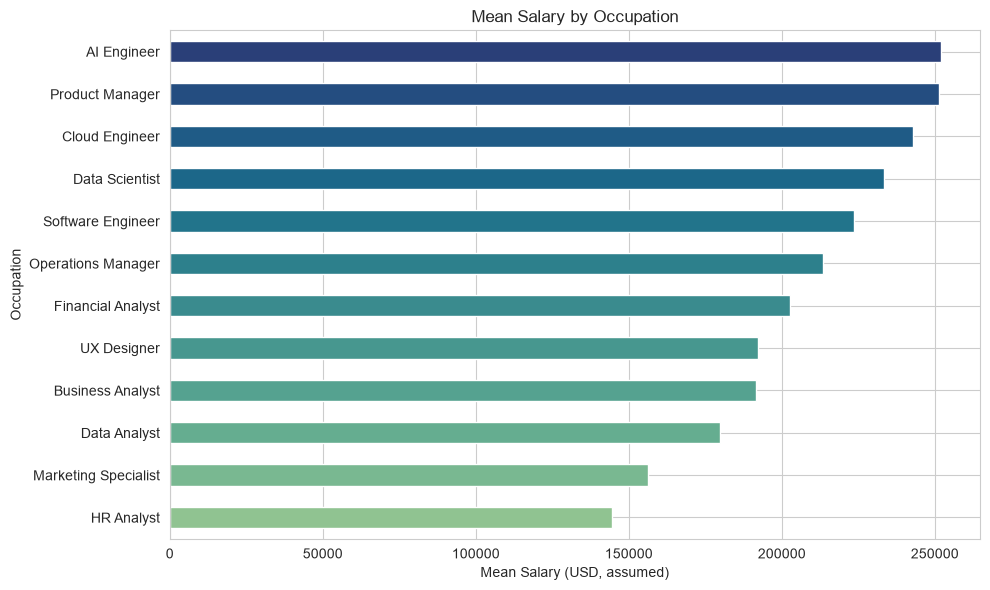

In [4]:
occ_salary = df.groupby('occupation', observed=True)['salary'].agg(['mean','median','std','count']).sort_values('mean', ascending=False)
print(occ_salary)

fig, ax = plt.subplots(figsize=(10,6))
occ_salary['mean'].sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('crest', len(occ_salary)))

ax.set_xlabel("Mean Salary (USD, assumed)")
ax.set_ylabel("Occupation")
ax.set_title("Mean Salary by Occupation")
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q3_occupation_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** AI Engineer ($252,147) and Product Manager ($251,254) top the list; HR Analyst ($144,604) and Marketing Specialist ($156,345) are lowest -- a ~74% spread between the highest- and lowest-paid occupations. All five Technology-field occupations (AI Engineer, Product Manager, Cloud Engineer, Data Scientist, Software Engineer) occupy the top five slots.

**Business insight:** Technology roles command a clear, consistent premium over Business/HR/Marketing roles in this dataset -- exactly the kind of role-based pay differential a comp team would expect to see and would use to justify differentiated pay bands by function.

**Recommendation:** Use occupation, not field, as the primary grouping variable for pay-band design -- field is too coarse (Technology alone spans a $30K range across its five occupations).

## Q4. Industry / field salary comparison

**Business relevance:** industry-level positioning, one level up from occupation. **Reminder:** `field` maps 1:1 from `occupation` except Technology (5 occupations roll up into it), so Technology's aggregate stats reflect a mix of several distinct roles.

                          mean    median   count
field                                           
Technology       230471.052998  228877.0  250275
Operations       213447.475852  210618.0   41639
Finance          202581.415425  198506.0   41815
Design           192173.979590  187592.0   41842
Business         191619.731466  187119.0   41302
Marketing        156345.184921  151683.5   41542
Human Resources  144604.000337  140343.0   41557


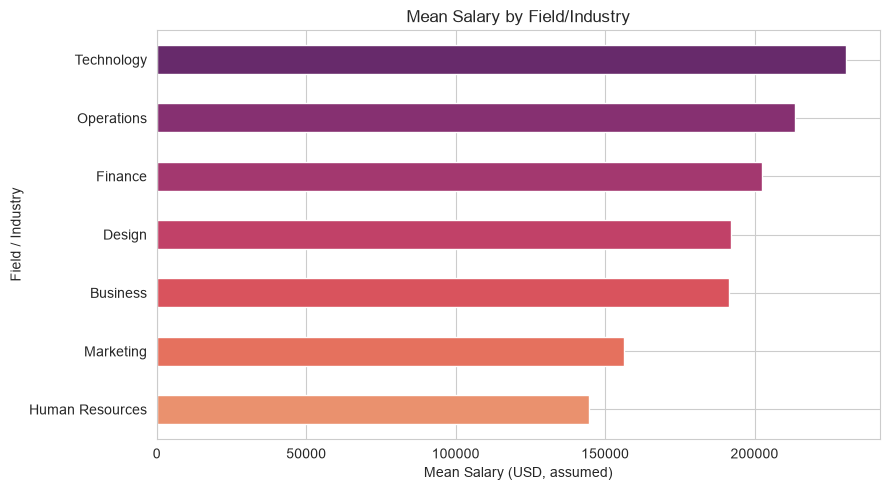

In [5]:
field_salary = df.groupby('field', observed=True)['salary'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print(field_salary)

fig, ax = plt.subplots(figsize=(9,5))
field_salary['mean'].sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('flare', len(field_salary)))

ax.set_xlabel('Mean Salary (USD, assumed)')
ax.set_ylabel("Field / Industry")
ax.set_title('Mean Salary by Field/Industry')
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q4_field_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Technology leads at $230,471 mean, but this blends five occupations spanning $223K-$252K -- a meaningfully wide range hidden inside one "field" label. Human Resources is lowest at $144,604.

**Business insight:** Field-level aggregation understates the real variation a comp team needs to see; averaging AI Engineer and Software Engineer together into "Technology" masks a >$28K gap between them.

**Recommendation:** Present field-level figures only as a summary layer in the dashboard, with drill-through to occupation-level detail -- never as the sole level of analysis.

## Q5. Experience vs. Salary

**Business relevance:** tests whether experience is a meaningful, monotonic driver of pay -- foundational for any compensation model.

Correlation (years_of_experience, salary): 0.3758
years_of_experience
0      95836.520081
1     118406.455371
2     161640.925001
3     172412.649689
4     182428.254864
5     189400.560855
6     195711.719891
7     200069.050295
8     205954.902068
9     210139.258117
10    213393.837294
11    216663.234851
12    219317.083699
13    221852.963845
14    225446.373729
15    228102.690457
16    229892.523040
17    231509.991524
18    232540.532706
19    235615.130592
20    237415.602208
21    238520.879346
22    240266.465098
23    241831.202649
24    242799.461863
25    243199.456012
Name: salary, dtype: float64


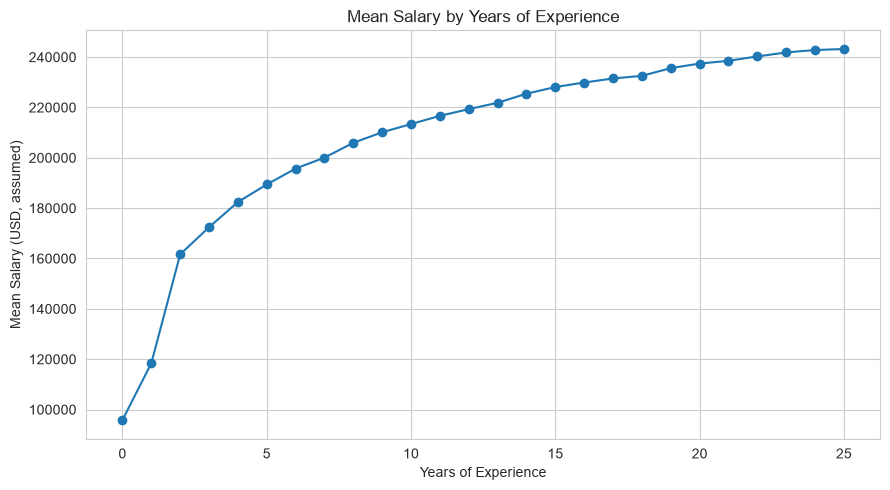

In [6]:
exp_salary = df.groupby('years_of_experience')['salary'].mean()
corr_exp_salary = df['years_of_experience'].corr(df['salary'])
print(f"Correlation (years_of_experience, salary): {corr_exp_salary:.4f}")
print(exp_salary)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(exp_salary.index, exp_salary.values, marker='o')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Mean Salary (USD, assumed)')
ax.set_title('Mean Salary by Years of Experience')
plt.tight_layout()
fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q5_experience_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Correlation between experience and salary is a moderate **r = 0.376** -- clearly positive but far from a straight line. The real story is in the curve shape: salary nearly doubles from 0 years ($95,837) to 5 years ($189,401, +98%), then grows much more slowly afterward (+29% from 5 to 25 years, $189,401 -> $243,199). This is a classic diminishing-returns experience curve, not a straight-line relationship.

**Business insight:** Early-career years are compensated much more steeply than senior-career years in this dataset. A linear regression term on experience alone would understate early-career pay growth and overstate late-career growth -- this is a strong signal to include a non-linear (e.g. log or polynomial) transform of experience in Phase 7 modeling, not just the raw variable.

**Recommendation:** For Phase 7, test `log(years_of_experience + 1)` or a spline/binned version alongside the raw variable, and compare model fit -- the shape of this curve suggests non-linear terms will meaningfully outperform a linear-only specification.

## Q6. Education vs. Salary

**Business relevance:** tests whether formal education level is priced into compensation in this dataset.

                          mean    median           std
education_level                                       
High School      167231.238102  161541.5  69670.376280
Bachelor         195058.404252  190094.0  78762.942679
Master           221241.840297  218133.0  85343.227614
PhD              244450.696168  247291.5  88379.707686


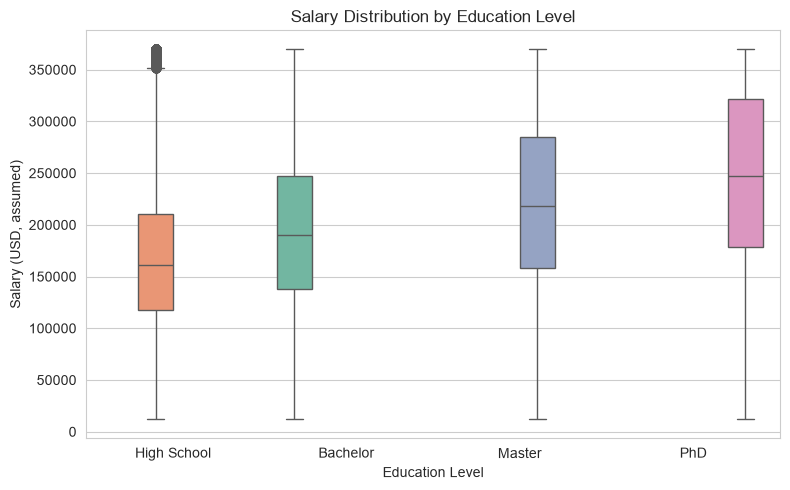

In [7]:
edu_salary = df.groupby('education_level', observed=True)['salary'].agg(['mean','median','std']).reindex(['High School','Bachelor','Master','PhD'])
print(edu_salary)

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='education_level', y='salary',hue='education_level', order=['High School','Bachelor','Master','PhD'], palette='Set2', legend=False, ax=ax)

ax.set_title('Salary Distribution by Education Level')
ax.set_xlabel("Education Level")
ax.set_ylabel("Salary (USD, assumed)")
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q6_education_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Salary rises monotonically with education: High School ($167,231) -> Bachelor ($195,058) -> Master ($221,242) -> PhD ($244,451), a 46% gap between the extremes. Unlike gender (see Q7), this is a clear, orderly gradient.

**Business insight:** Education level is a strong, well-behaved candidate predictor for the Phase 7 regression model, and the monotonic pattern makes it an easy one to explain to non-technical stakeholders.

**Recommendation:** Encode `education_level` as an ordinal feature (not one-hot) for tree-based models where ordering is meaningful, and consider both an ordinal and one-hot encoding for linear models to test which captures the relationship better.

## Q7. Gender distribution and pay

**Business relevance:** pay-equity is one of the most consequential questions a real comp team asks. We report descriptively; formal significance testing is deferred to Phase 6 (hypothesis testing).

                 mean    median           std   count
gender                                               
Female  206738.818528  199881.0  85828.462506  166654
Male    207116.750099  200572.0  85769.323391  165830
Other   207174.390446  200238.5  85984.011214  167488


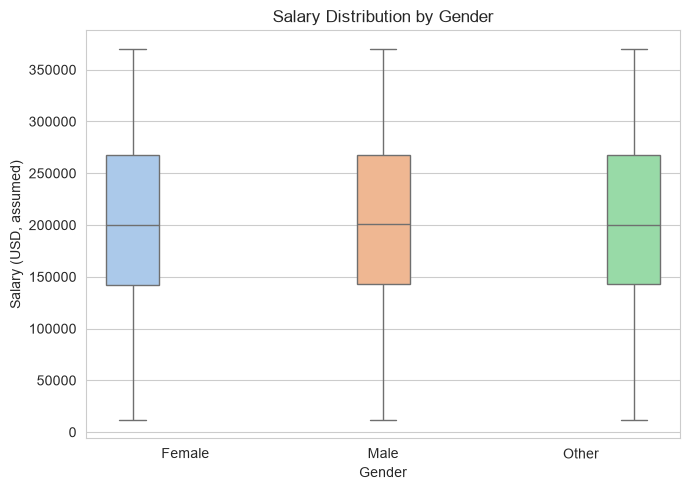

In [8]:
gender_salary = df.groupby('gender', observed=True)['salary'].agg(['mean','median','std','count'])
print(gender_salary)

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='gender', y='salary',hue="gender", palette='pastel', legend=False, ax=ax,)

ax.set_xlabel("Gender")
ax.set_ylabel("Salary (USD, assumed)")
ax.set_title('Salary Distribution by Gender')
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q7_gender_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Mean salaries are nearly identical across gender groups: Female $206,739, Male $207,117, Other $207,174 -- a spread of under 0.3%, far smaller than any of the other groupings we've examined (compare to the 46% education gap or 174% occupation gap).

**Business insight:** On its face, this dataset shows no meaningful gender pay gap. Given everything we know about this data's synthetic, independently-generated construction, this is very likely a generation artifact (gender was probably assigned independently of salary) rather than a genuine finding about real-world pay equity. We should not present this as "proof gender doesn't affect pay" -- that would overclaim what a synthetic dataset can tell us.

**Recommendation:** Report this finding with the caveat explicit: "in this dataset" and "given its synthetic construction, this should not be read as evidence about real-world pay equity, positive or negative." We'll run a formal ANOVA/t-test in Phase 6 to confirm the difference is not statistically significant, which would support (not create) this conclusion.

## Q8. Company size comparison

**Business relevance:** tests the common assumption that larger companies pay more.

                       mean    median   count
company_size                                 
Small         176164.006931  169463.0  124517
Medium        195039.791659  188625.0  124618
Large         220214.928122  216327.5  124948
Enterprise    236263.285847  235363.0  125889


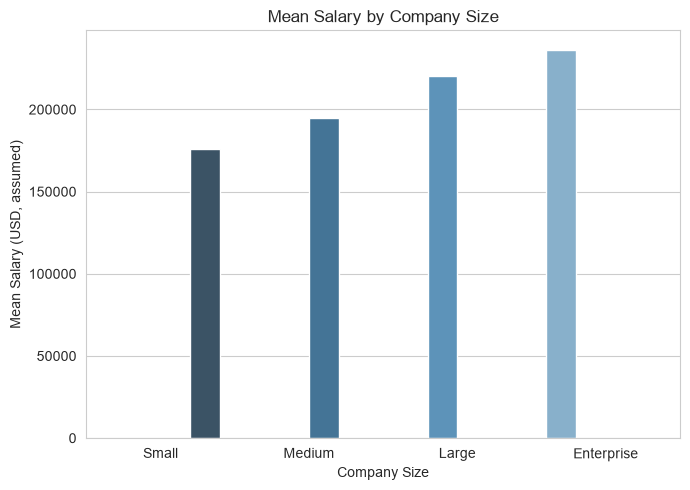

In [9]:
size_salary = df.groupby('company_size', observed=True)['salary'].agg(['mean','median','count']).reindex(['Small','Medium','Large','Enterprise'])
print(size_salary)

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=df, x='company_size', y='salary', hue="company_size", order=['Small','Medium','Large','Enterprise'], palette='Blues_d',
            legend=False, errorbar=None, ax=ax)

ax.set_xlabel("Company Size")
ax.set_ylabel("Mean Salary (USD, assumed)")
ax.set_title("Mean Salary by Company Size")
plt.tight_layout()

# Save the figure.
fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q8_companysize_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Salary rises monotonically with company size: Small ($176,164) -> Medium ($195,040) -> Large ($220,215) -> Enterprise ($236,263), a 34% gap between smallest and largest.

**Business insight:** This matches conventional wisdom (larger companies typically pay more, often due to more capital, more structured pay bands, and more competitive positioning) and is a clean, intuitive relationship for the dashboard's executive summary.

**Recommendation:** Include company_size as a modeling feature and as a top-level Power BI filter -- it's one of the cleanest, most interpretable relationships in the dataset.

## Q9. Employment type comparison

**Business relevance:** quantifies the pay gap between full-time and non-traditional arrangements (internship, freelance, part-time, WFH).

                          mean    median   count
employment_type                                 
part_time        208927.107222  201059.0  100166
work_from_home   208768.537918  200829.0   99623
freelance        208661.548779  200780.0  100166
full_time        208393.754798  199937.5   99722
internship       200323.751463  198550.0  100295


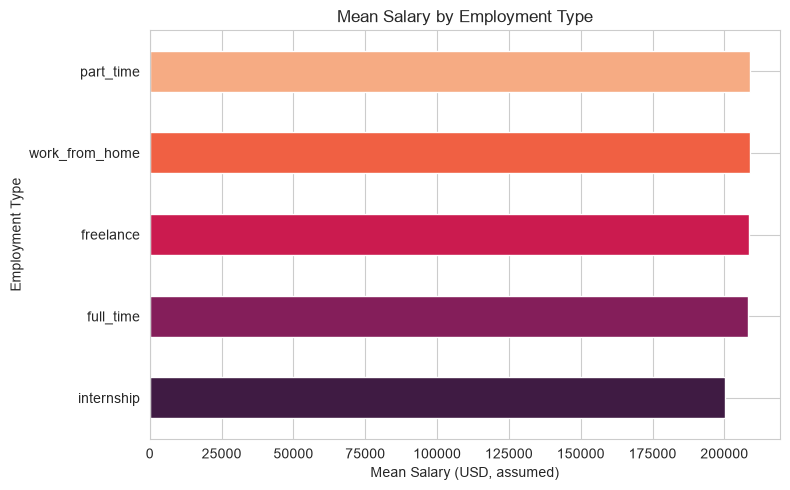

In [10]:
emp_salary = df.groupby('employment_type', observed=True)['salary'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print(emp_salary)

fig, ax = plt.subplots(figsize=(8,5))
emp_salary['mean'].sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('rocket', len(emp_salary)))

ax.set_xlabel("Mean Salary (USD, assumed)")
ax.set_ylabel("Employment Type")
ax.set_title('Mean Salary by Employment Type')
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q9_employment_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Employment types are far closer together than expected: part_time ($208,927), work_from_home ($208,769), freelance ($208,662), and full_time ($208,394) are within 0.3% of each other, with only internship ($200,324) meaningfully lower -- and even that gap is just ~4%, much smaller than typical real-world intern-vs-full-time pay differentials.

**Business insight:** This is a notable data-generation artifact worth naming directly: in reality, freelance and part-time work typically show far more pay variance and often lower averages than full-time roles, and internships typically pay dramatically less. The near-uniformity here reinforces the synthetic-data conclusion from Phase 2/3 -- pay level appears to be set largely independent of employment arrangement.

**Recommendation:** Do not use this dataset's employment-type pay parity as a real-world claim in any resume bullet or interview narrative ("gig workers are paid the same as full-time employees") -- flag it explicitly as a synthetic-data limitation instead.

## Q10. Year-over-year salary trends

**Business relevance:** tests whether pay levels are rising over the observed window (2022-2025). **Caveat:** this is a repeated cross-section, not a longitudinal panel -- we're observing the average of a new synthetic sample each year, not the same people getting raises.

               mean    median   count
year                                 
2022  198148.256719  191421.0  125133
2023  204473.570613  197712.0  125041
2024  210082.710779  203399.0  125105
2025  215363.997626  209192.0  124693

YoY % change in mean salary:
year
2022         NaN
2023    3.192213
2024    2.743210
2025    2.513908
Name: mean, dtype: float64


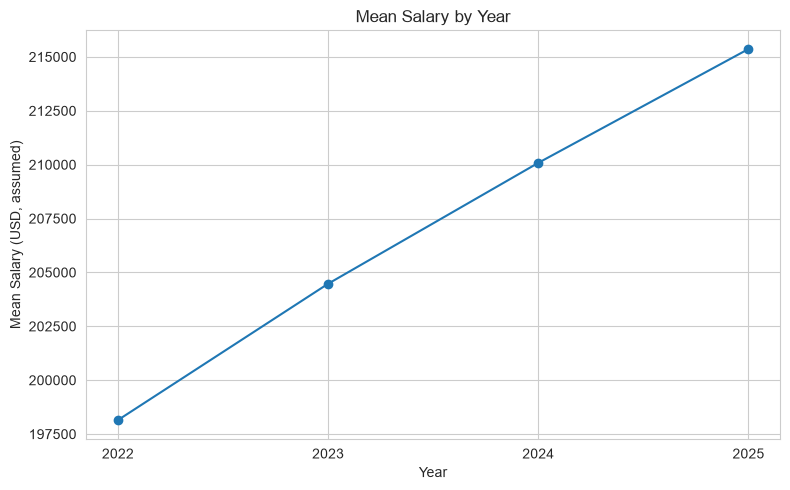

In [11]:
# Calculate salary statistics for each year.
year_salary = df.groupby('year')['salary'].agg(['mean','median','count'])
print(year_salary)
# Calculate year-over-year percentage change in mean salary.
yoy_pct = year_salary['mean'].pct_change() * 100
print()
print("YoY % change in mean salary:")
print(yoy_pct)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(year_salary.index, year_salary['mean'], marker='o')

ax.set_xlabel('Year')
ax.set_ylabel('Mean Salary (USD, assumed)')
ax.set_title('Mean Salary by Year')
ax.set_xticks(year_salary.index)
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q10_year_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


**Interpretation:** Mean salary rose from $198,148 (2022) to $215,364 (2025), a cumulative +8.7% over 3 years, but year-over-year growth is decelerating: +3.19% (2023), +2.74% (2024), +2.51% (2025).

**Business insight:** There's a genuine, if modest, upward trend -- useful for time-based modeling -- but the decelerating growth rate means a naive "salary is growing ~3%/year forever" extrapolation would overstate future compensation growth if this pattern continues.

**Recommendation:** Include `year` as a numeric or ordinal feature in Phase 7 models to capture this trend, but caveat any forward-looking salary projection with the decelerating growth pattern observed here.

## Q11. Monthly / seasonal trends

**Business relevance:** checks for any seasonal hiring or pay-setting pattern (e.g., budget-cycle effects).

                mean  count
month                      
1      206873.113023  41328
2      207073.793226  41804
3      206781.211501  41546
4      208218.180603  41760
5      207095.316712  41312
6      206911.047351  41963
7      207048.225288  41751
8      207257.579102  41775
9      207155.248346  41559
10     206720.794110  41867
11     206812.652295  41541
12     206173.037159  41766


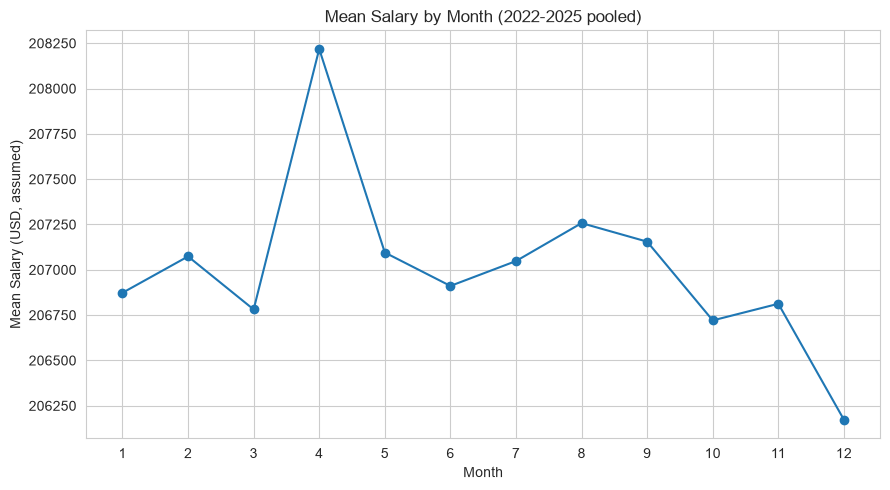

In [12]:
month_salary = df.groupby('month')['salary'].agg(['mean','count'])
print(month_salary)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(month_salary.index, month_salary['mean'], marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Salary (USD, assumed)')
ax.set_title('Mean Salary by Month (2022-2025 pooled)')
ax.set_xticks(range(1,13))
plt.tight_layout()

fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q11_month_salary.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

**Interpretation:** Mean salary is essentially flat across all 12 months, ranging narrowly from $206,173 (December) to $208,218 (April) -- a spread of under 1%. There is no visible seasonal pattern.

**Business insight:** Month/seasonality carries no meaningful salary signal in this dataset. Unlike `year`, which showed a real trend, `month` is not a useful predictor.

**Recommendation:** Exclude raw `month` from the regression feature set (or keep only as the `quarter` bucket for reporting granularity) -- including a 12-level feature with no real signal adds model complexity without predictive value.

## Q12. Record volume over time

**Important framing note:** this dataset has no job-posting or hiring-event field, so we cannot measure real hiring trends. What we *can* measure is the volume of salary records per year/month, which we report as sample composition, not as a hiring-activity signal -- conflating the two would be exactly the kind of fabricated finding we're avoiding.

In [13]:
# Calculate the number of records for each year.
volume_by_year = (df.groupby("year").size().reset_index(name="Record Count"))

# Calculate the number of records for each month.
volume_by_month = (df.groupby("month").size().reset_index(name="Record Count"))

print("Record Volume by Year")
display(volume_by_year)

print("\nRecord Volume by Month")
display(volume_by_month)

Record Volume by Year


,year,Record Count
0,2022,125133
1,2023,125041
2,2024,125105
3,2025,124693



Record Volume by Month


,month,Record Count
0,1,41328
1,2,41804
2,3,41546
3,4,41760
4,5,41312
5,6,41963
6,7,41751
7,8,41775
8,9,41559
9,10,41867


**Interpretation:** Record volume is essentially flat across years (~125,000/year, max deviation <0.4%) and months (~41,300-42,000/month, max deviation <1.6%). There is no growth or seasonal pattern in record counts.

**Business insight:** This confirms the volume is a sampling artifact of the synthetic generation process, not a real hiring-activity signal -- exactly why we're reporting it as "record volume," not "hiring trend."

**Recommendation:** Do not present this as evidence of hiring trends in the README or dashboard; label it explicitly as sample composition over time.

## Q13. Correlation analysis (numeric features)

**Business relevance:** summarizes linear relationships among the numeric fields before we move into formal hypothesis testing in Phase 6.

                     years_of_experience    salary      year     month
years_of_experience             1.000000  0.375845 -0.002795 -0.001408
salary                          0.375845  1.000000  0.074541 -0.002141
year                           -0.002795  0.074541  1.000000 -0.000819
month                          -0.001408 -0.002141 -0.000819  1.000000


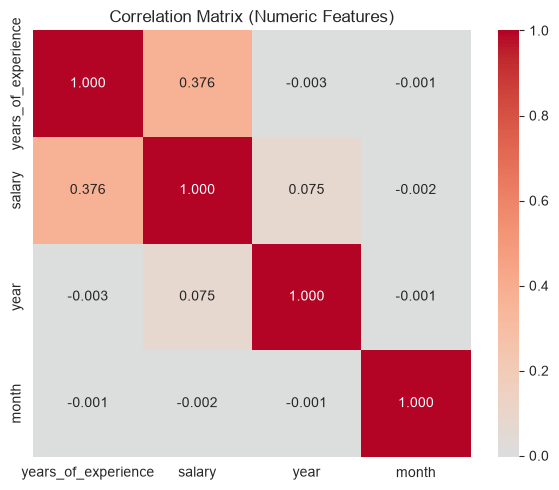

In [14]:
numeric_cols = ['years_of_experience', 'salary', 'year', 'month']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

# Create the figure:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.3f')

ax.set_title('Correlation Matrix (Numeric Features)')
plt.tight_layout()

# Save the figure.
fig.savefig(r"C:\Users\rashm\Downloads\Job Market\docs\figures\q13_correlation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

**Interpretation:** `years_of_experience` and `salary` show the strongest relationship (r=0.376, moderate). `year` and `salary` show a weak positive correlation (r=0.075), consistent with the modest upward trend found in Q10. `month` shows essentially no correlation with anything (|r| < 0.003).

**Business insight:** Experience is, by a wide margin, the strongest linear numeric predictor of salary among the four numeric fields -- though Q5 showed the true relationship is non-linear. Year contributes a small independent trend signal. Month contributes nothing and is a safe drop from the numeric feature set.

**Recommendation:** For Phase 7 regression, prioritize `years_of_experience` (with a non-linear transform) and `year` as numeric predictors; drop raw `month` (retain only `quarter` for categorical/reporting use).